### Used libraries

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Load datasets from csv

In [16]:
df = pd.read_csv('datasets/job_offer_cleaned.csv', delimiter= ',')
print(df.shape)
df.head(3)

(5935, 11)


,Unnamed: 0,profil,market_category,societe,type_contrat,lieu,limite_date,offers_date,title_clean,mission_clean,profil_clean
0,0,o solides connaissances en electronique indust...,Ingénierie / industrie / BTP,groupe sipromad,contrat cdi,aucun lieu,0001-01-01,13/05/2025,electronicien,électronicien industriel maintenance réparatio...,o solides connaissances electronique industrie...
1,1,- formation bac+3 a bac+5 en informatique\n- m...,Informatique / web,astek madagascar,contrat cdd,aucun lieu,0001-01-01,28/09/2024,engineer,participez projets transformation digitale var...,formation bac bac informatique maitrise techno...
2,2,"• bac +4/5 en gestion, grh, sociologie, droit,...",Management / RH,inviso group,contrat cdi,antananarivo,0001-01-01,14/02/2025,developpement rh,rattaché directrice ressources humaines groupe...,bac gestion grh sociologie droit psychologie m...


### Visualization of the count of job offers by contract type

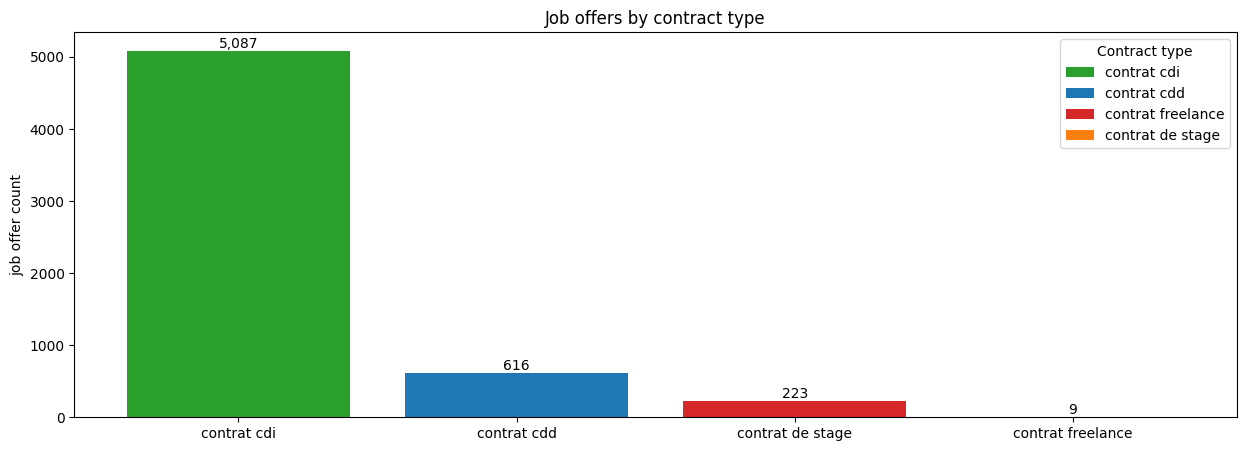

In [15]:
fig, ax = plt.subplots(figsize = (15,5))

job_offer_count = df[df['type_contrat'].isin(['contrat cdi', 'contrat cdd', 'contrat freelance', 'contrat de stage'])]['type_contrat'].value_counts().index
contract_type = df[df['type_contrat'].isin(['contrat cdi', 'contrat cdd', 'contrat freelance', 'contrat de stage'])]['type_contrat'].value_counts().values
bar_labels = ['contrat cdi', 'contrat cdd', 'contrat freelance', 'contrat de stage']
bar_colors = ['tab:green', 'tab:blue', 'tab:red', 'tab:orange']

bars = ax.bar(job_offer_count, contract_type, label=bar_labels, color=bar_colors)
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('job offer count')
ax.set_title('Job offers by contract type')
ax.legend(title='Contract type')
plt.show()

### Visualization of the count of job offers by TOP 10 job localization

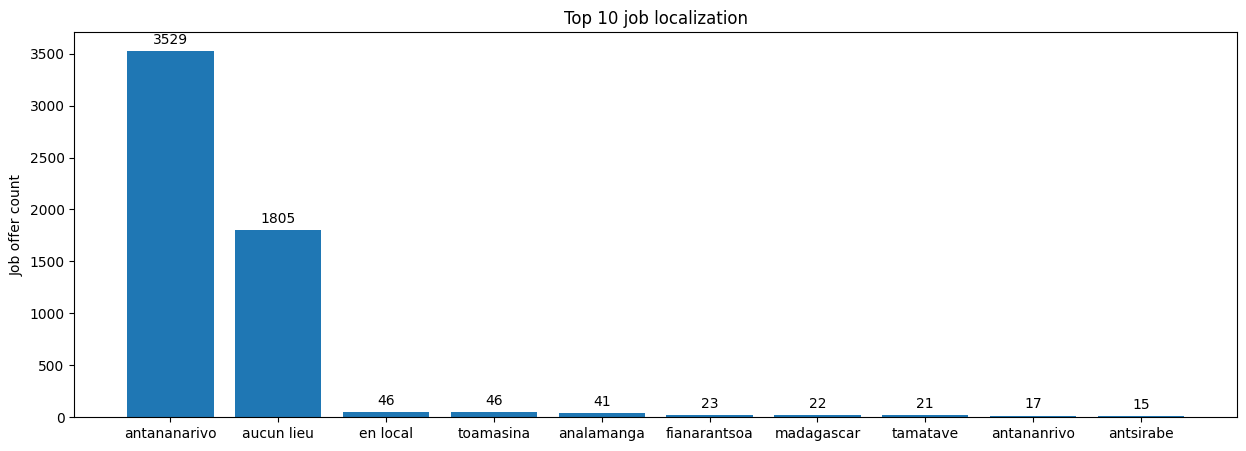

In [13]:
fig, ax = plt.subplots(figsize=(15,5))

localization = df['lieu'].value_counts().head(10)

bars = ax.bar(localization.index, localization.values, color='tab:blue')

ax.bar_label(bars, padding=3)

ax.set_ylabel('Job offer count')
ax.set_title('Top 10 job localization')

# plt.xticks(rotation=45)
plt.show()

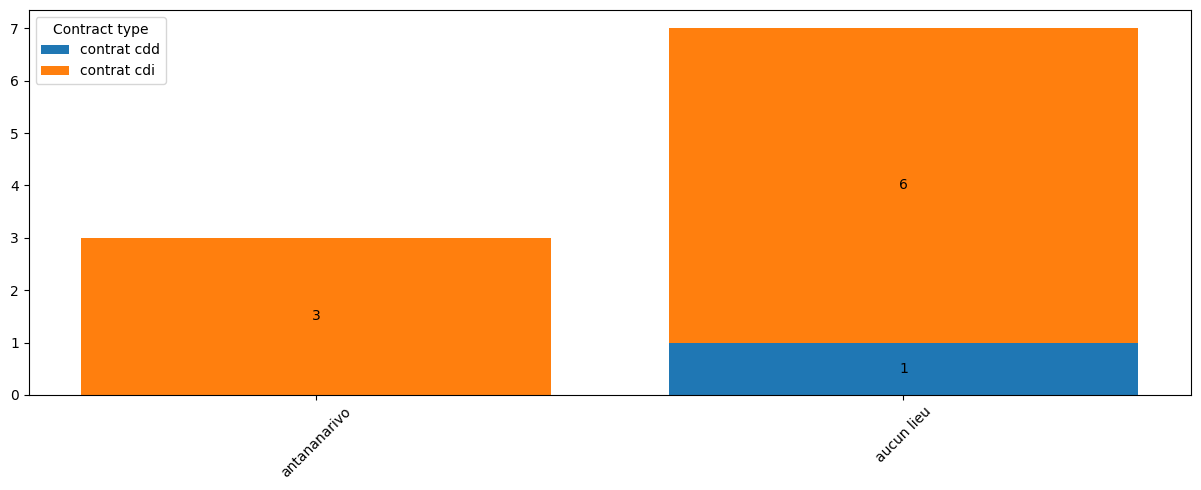

In [69]:
fig, ax = plt.subplots(figsize=(15,5))
cross_tab = pd.crosstab(df['lieu'].head(10), df['type_contrat'])
bottom = np.zeros(len(cross_tab ))

for contract in cross_tab .columns:
    values = cross_tab [contract].values
    bars = ax.bar(cross_tab .index, values, bottom=bottom, label=contract)
    ax.bar_label(
        bars,
        labels=[v if v > 0 else '' for v in values],
        label_type='center'
    )
    bottom += values

ax.legend(title='Contract type')
plt.xticks(rotation=45)

plt.show()